In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay
)

from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

In [4]:
inicio = time.perf_counter()

SEED = 123

In [5]:
df = pd.read_csv("final_dataset.csv")

df["precipitation"] = df["precipitation"].replace("Extreme rain", "Rain")

X = df.drop(columns=["precipitation"])
y = df["precipitation"]

labels = ["Rain", "No rain"]

y.value_counts()

precipitation
No rain    431380
Rain        37431
Name: count, dtype: int64

In [6]:
def criar_modelo_svm_rbf(seed=SEED):
    return Pipeline(steps=[
        ("undersampling", RandomUnderSampler(random_state=seed)),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ("scaler", StandardScaler(with_mean=False)),
        ("modelo", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            random_state=seed
        ))
    ])

def metricas_da_matriz(cm):
    """
    Considerando labels = ['Rain', 'No rain']
    """
    VP = cm[0, 0]
    FN = cm[0, 1]
    FP = cm[1, 0]
    VN = cm[1, 1]

    acuracia = (VP + VN) / cm.sum()
    sensibilidade = VP / (VP + FN) if (VP + FN) > 0 else np.nan
    especificidade = VN / (VN + FP) if (VN + FP) > 0 else np.nan

    return {
        "Acurácia": acuracia,
        "Sensibilidade": sensibilidade,
        "Especificidade": especificidade
    }

In [7]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

cm_total = np.zeros((2, 2), dtype=int)
matrizes_folds = {}
resultados = []

y_test_total = []
y_score_total = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):

    print(f"Rodando fold {fold}...")

    X_train_fold = X.iloc[train_idx]
    X_test_fold = X.iloc[test_idx]
    y_train_fold = y.iloc[train_idx]
    y_test_fold = y.iloc[test_idx]

    modelo_svm_rbf = criar_modelo_svm_rbf()
    modelo_svm_rbf.fit(X_train_fold, y_train_fold)

    y_pred_fold = modelo_svm_rbf.predict(X_test_fold)

    cm_fold = confusion_matrix(
        y_test_fold,
        y_pred_fold,
        labels=labels
    )

    cm_total += cm_fold
    matrizes_folds[f"Fold {fold}"] = cm_fold

    # Para ROC no SVM RBF usamos decision_function, não predict_proba
    y_score_fold = modelo_svm_rbf.decision_function(X_test_fold)

    # Garante que o score positivo represente a classe Rain
    classes_modelo = modelo_svm_rbf.named_steps["modelo"].classes_

    if classes_modelo[1] != "Rain":
        y_score_fold = -y_score_fold

    y_test_bin_fold = (y_test_fold == "Rain").astype(int)

    metricas = metricas_da_matriz(cm_fold)
    metricas["AUC"] = roc_auc_score(y_test_bin_fold, y_score_fold)

    for metrica, valor in metricas.items():
        resultados.append({
            "Fold": fold,
            "Métrica": metrica,
            "Valor": valor
        })

    y_test_total.extend(y_test_bin_fold.to_numpy())
    y_score_total.extend(y_score_fold)

Rodando fold 1...
Rodando fold 2...
Rodando fold 3...
Rodando fold 4...
Rodando fold 5...


In [8]:
matriz_confusao_total = pd.DataFrame(
    cm_total,
    index=["Real Rain", "Real No rain"],
    columns=["Predito Rain", "Predito No rain"]
)

resultados_cv = pd.DataFrame(resultados)

tabela_cv = resultados_cv.pivot(
    index="Métrica",
    columns="Fold",
    values="Valor"
)

tabela_cv.columns = [f"Fold {col}" for col in tabela_cv.columns]
tabela_cv["Média"] = tabela_cv.mean(axis=1)
tabela_cv["DP"] = tabela_cv.std(axis=1)

display(matriz_confusao_total)
display(tabela_cv)

,Predito Rain,Predito No rain
Real Rain,28329,9102
Real No rain,122435,308945


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Média,DP
Métrica,,,,,,,
AUC,0.800460,0.804769,0.802709,0.802419,0.806115,0.803294,0.001963
Acurácia,0.720796,0.723011,0.714895,0.719535,0.718884,0.719424,0.002667
Especificidade,0.718172,0.720200,0.711020,0.716155,0.715344,0.716178,0.003081
Sensibilidade,0.751035,0.755410,0.759551,0.758483,0.759685,0.756833,0.003283


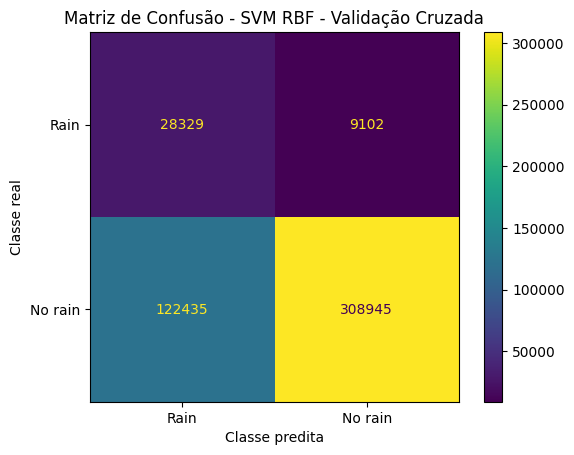

In [9]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_total.astype(int),
    display_labels=labels
).plot(values_format="d")

plt.title("Matriz de Confusão - SVM RBF - Validação Cruzada")
plt.xlabel("Classe predita")
plt.ylabel("Classe real")

plt.savefig("matriz_confusao_svm_rbf.png", dpi=300, bbox_inches="tight")

plt.show()

AUC geral: 0.8033029457961748


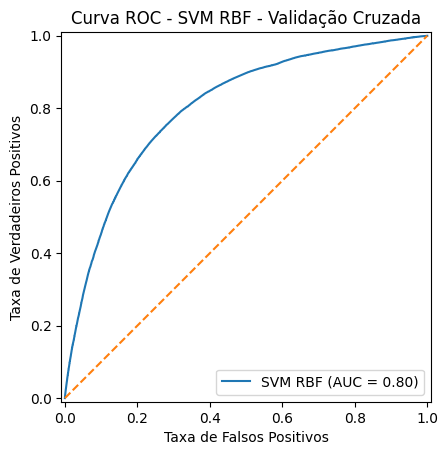

In [10]:
y_test_total = np.array(y_test_total)
y_score_total = np.array(y_score_total)

fpr, tpr, thresholds = roc_curve(y_test_total, y_score_total)
auc = roc_auc_score(y_test_total, y_score_total)

print("AUC geral:", auc)

RocCurveDisplay(
    fpr=fpr,
    tpr=tpr,
    roc_auc=auc,
    estimator_name="SVM RBF"
).plot()

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC - SVM RBF - Validação Cruzada")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")

plt.savefig("curva_roc_svm_rbf.png", dpi=300, bbox_inches="tight")

plt.show()

In [11]:
fim = time.perf_counter()

tempo_total = fim - inicio

horas = int(tempo_total // 3600)
minutos = int((tempo_total % 3600) // 60)
segundos = tempo_total % 60

print(f"Tempo total do experimento: {horas}h {minutos}min {segundos:.2f}s")

Tempo total do experimento: 1h 10min 17.05s


In [12]:
60*60+60*13+35,11

(4415, 11)